In [ ]:
# ============================================================
# NOTEBOOK 7 — S-XGBOOST
# CELL 1 — IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
print("Libraries imported successfully.")

# ============================================================
# CELL 2 — DEFINE DIRECTORIES
# ============================================================
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / "processed"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"
PROCESSED_DIR = Path("../data/processed")

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Project directory:", BASE_DIR)
print("Processed data:", PROCESSED_DIR)
print("Models directory:", MODELS_DIR)
print("Results directory:", RESULTS_DIR)

Libraries imported successfully.
Project directory: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks
Processed data: ..\data\processed
Models directory: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models
Results directory: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\results


In [3]:
# ============================================================
# CELL 3 — LOAD SHAP-SELECTED TRAINING DATA
# ============================================================

X_train_shap = pd.read_csv(
    PROCESSED_DIR / "X_train_shap.csv"
)
y_train_shap = pd.read_csv(
    PROCESSED_DIR / "y_train_shap.csv"
).squeeze()

print("=" * 65)
print("SHAP-SELECTED TRAINING DATA")
print("=" * 65)

print("X_train_shap shape:", X_train_shap.shape)
print("y_train_shap shape:", y_train_shap.shape)

print("\nTarget distribution:")
print(y_train_shap.value_counts().sort_index())

SHAP-SELECTED TRAINING DATA
X_train_shap shape: (658, 47)
y_train_shap shape: (658,)

Target distribution:
RISK_LABEL
0    329
1    329
Name: count, dtype: int64


In [5]:
# ============================================================
# CELL 4 — LOAD ORIGINAL TEST DATA
# ============================================================

X_test_clean = pd.read_csv(
    PROCESSED_DIR / "X_test_clean.csv"
)

y_test_clean = pd.read_csv(
    PROCESSED_DIR / "y_test_clean.csv"
).squeeze()

print("=" * 65)
print("ORIGINAL TEST DATA")
print("=" * 65)

print("X_test_clean shape:", X_test_clean.shape)
print("y_test_clean shape:", y_test_clean.shape)

print("\nTest target distribution:")
print(y_test_clean.value_counts().sort_index())

ORIGINAL TEST DATA
X_test_clean shape: (114, 58)
y_test_clean shape: (114,)

Test target distribution:
RISK_LABEL
0    83
1    31
Name: count, dtype: int64


In [6]:
# ============================================================
# CELL 5 — LOAD SHAP SELECTED FEATURES
# ============================================================

selected_features_df = pd.read_csv(
    RESULTS_DIR / "shap_selected_features.csv"
)

selected_features = (
    selected_features_df["Feature"]
    .tolist()
)

print("Number of selected features:", len(selected_features))

print("\nSelected features:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i:02d}. {feature}")

Number of selected features: 47

Selected features:
01. GPA_S1
02. Hopeless/unmotivated
03. Sleep_hrs
04. LAB_AVG
05. Programme prepares for career
06. Concentration in self-study
07. Adequate supervision
08. CA_AVG
09. Financial_diff
10. Employment_hrs
11. Can improve performance
12. Self-motivates
13. Sense of belonging
14. Manages time effectively
15. Early intervention provided
16. Persists when difficult
17. Peer study groups effective
18. Anxious about assessments
19. Takes rest breaks
20. Seeks help when stuck
21. Regular exercise
22. Participates in class
23. Considered break
24. Age_group
25. Understands content pre-exam
26. CLIN_AVG
27. Takes organised notes
28. Physical health affected
29. ATT_RATE
30. Lecturers approachable
31. Sets academic goals
32. Study_hrs_day
33. Completes readings
34. EXAM_AVG
35. Confident in clinical skills
36. Prepared for clinical assess
37. Rotations affect performance
38. Self_risk_percep
39. Schedule conflicts
40. Gender
41. Sleep difficulty
4

In [7]:
# ============================================================
# CELL 6 — SELECT SAME FEATURES FROM ORIGINAL TEST DATA
# ============================================================

missing_test_features = [
    feature
    for feature in selected_features
    if feature not in X_test.columns
]

print("Missing selected features in test data:",
    len(missing_test_features))

if missing_test_features:
    print(missing_test_features)
    raise ValueError(
        "Some SHAP-selected features are missing from X_test."
    )

X_test_shap = X_test[
    selected_features
].copy()

print("\nX_test_shap shape:", X_test_shap.shape)

Missing selected features in test data: 0

X_test_shap shape: (114, 47)


In [8]:
# ============================================================
# CELL 7 — VERIFY TRAIN/TEST FEATURE ALIGNMENT
# ============================================================

print("Training features:", X_train_shap.shape[1])
print("Test features:", X_test_shap.shape[1])

print(
    "\nFeature order identical:",
    list(X_train_shap.columns) == list(X_test_shap.columns)
)

if list(X_train_shap.columns) != list(X_test_shap.columns):
    raise ValueError(
        "Training and test feature order does not match."
    )

print("✓ S-XGBoost train/test features are aligned.")

Training features: 47
Test features: 47

Feature order identical: True
✓ S-XGBoost train/test features are aligned.


In [12]:
# ============================================================
# CELL 8 — CHECK MISSING VALUES
# ============================================================

train_missing = X_train_shap.isnull().sum().sum()
test_missing = X_test_shap.isnull().sum().sum()

print("Missing values in training:", train_missing)
print("Missing values in test:", test_missing)

if train_missing > 0 or test_missing > 0:
    print("\nWARNING: Missing values detected.")
else:
    print("\n✓ No missing values detected.")
    
# ============================================================
# CELL 9 — VERIFY TARGET DISTRIBUTION
# ============================================================

print("Training target distribution:")
print(y_train_shap.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test_clean.value_counts().sort_index())

Missing values in training: 0
Missing values in test: 0

✓ No missing values detected.
Training target distribution:
RISK_LABEL
0    329
1    329
Name: count, dtype: int64

Test target distribution:
RISK_LABEL
0    83
1    31
Name: count, dtype: int64


In [13]:
# ============================================================
# CELL 10 — CREATE S-XGBOOST MODEL
# ============================================================

s_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print("S-XGBoost model created successfully.")

S-XGBoost model created successfully.


In [14]:
# ============================================================
# CELL 11 — TRAIN S-XGBOOST
# ============================================================

print("Training S-XGBoost...")

s_xgb.fit(
    X_train_shap,
    y_train_shap
)

print("✓ S-XGBoost training completed.")

Training S-XGBoost...
✓ S-XGBoost training completed.


In [15]:
# ============================================================
# CELL 12 — GENERATE S-XGBOOST PREDICTIONS
# ============================================================

y_pred_s = s_xgb.predict(
    X_test_shap
)

y_prob_s = s_xgb.predict_proba(
    X_test_shap
)[:, 1]

print("S-XGBoost predictions generated successfully.")

print("\nPrediction distribution:")
print(
    pd.Series(y_pred_s)
    .value_counts()
    .sort_index()
)

S-XGBoost predictions generated successfully.

Prediction distribution:
0    88
1    26
Name: count, dtype: int64


In [16]:
# ============================================================
# CELL 13 — EVALUATE S-XGBOOST
# ============================================================

accuracy_s = accuracy_score(
    y_test_clean,
    y_pred_s
)

precision_s = precision_score(
    y_test_clean,
    y_pred_s,
    zero_division=0
)

recall_s = recall_score(
    y_test_clean,
    y_pred_s,
    zero_division=0
)

f1_s = f1_score(
    y_test_clean,
    y_pred_s,
    zero_division=0
)

auc_s = roc_auc_score(
    y_test_clean,
    y_prob_s
)

print("=" * 65)
print("S-XGBOOST PERFORMANCE")
print("=" * 65)

print(f"Accuracy : {accuracy_s:.4f}")
print(f"Precision: {precision_s:.4f}")
print(f"Recall   : {recall_s:.4f}")
print(f"F1-score : {f1_s:.4f}")
print(f"ROC-AUC  : {auc_s:.4f}")

S-XGBOOST PERFORMANCE
Accuracy : 0.7105
Precision: 0.4615
Recall   : 0.3871
F1-score : 0.4211
ROC-AUC  : 0.6421


In [18]:
# ============================================================
# CELL 14 — CLASSIFICATION REPORT
# ============================================================

print("=" * 65)
print("S-XGBOOST CLASSIFICATION REPORT")
print("=" * 65)

print(
    classification_report(
        y_test_clean,
        y_pred_s,
        target_names=[
            "Not At-Risk",
            "At-Risk"
        ],
        zero_division=0
    )
)

S-XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not At-Risk       0.78      0.83      0.81        83
     At-Risk       0.46      0.39      0.42        31

    accuracy                           0.71       114
   macro avg       0.62      0.61      0.61       114
weighted avg       0.70      0.71      0.70       114



S-XGBoost Confusion Matrix:
[[69 14]
 [19 12]]


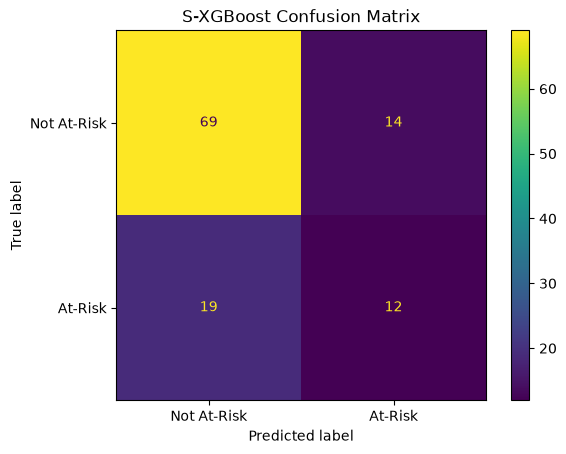

In [19]:
# ============================================================
# CELL 15 — CONFUSION MATRIX
# ============================================================

cm_s = confusion_matrix(
    y_test_clean,
    y_pred_s
)

print("S-XGBoost Confusion Matrix:")
print(cm_s)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_s,
    display_labels=[
        "Not At-Risk",
        "At-Risk"
    ]
)

disp.plot()

plt.title(
    "S-XGBoost Confusion Matrix"
)

plt.show()

In [20]:
# ============================================================
# CELL 16 — BASELINE VS S-XGBOOST
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "S-XGBoost"
    ],
    "Features": [
        58,
        len(selected_features)
    ],
    "Accuracy": [
        0.710526,
        accuracy_s
    ],
    "Precision": [
        0.458333,
        precision_s
    ],
    "Recall": [
        0.354839,
        recall_s
    ],
    "F1": [
        0.400000,
        f1_s
    ],
    "ROC_AUC": [
        0.650214,
        auc_s
    ]
})

display(comparison)

,Model,Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline XGBoost,58,0.710526,0.458333,0.354839,0.400000,0.650214
1,S-XGBoost,47,0.710526,0.461538,0.387097,0.421053,0.642052


In [21]:
# ============================================================
# CELL 17 — CALCULATE PERFORMANCE CHANGES
# ============================================================

baseline_auc = 0.650214
baseline_f1 = 0.400000
baseline_recall = 0.354839

auc_change = auc_s - baseline_auc
f1_change = f1_s - baseline_f1
recall_change = recall_s - baseline_recall

print("=" * 65)
print("PERFORMANCE CHANGE AFTER SHAP FEATURE SELECTION")
print("=" * 65)

print(f"ROC-AUC change : {auc_change:+.4f}")
print(f"F1 change      : {f1_change:+.4f}")
print(f"Recall change  : {recall_change:+.4f}")

PERFORMANCE CHANGE AFTER SHAP FEATURE SELECTION
ROC-AUC change : -0.0082
F1 change      : +0.0211
Recall change  : +0.0323


In [22]:
# ============================================================
# CELL 18 — SAVE S-XGBOOST MODEL
# ============================================================

s_xgb_model_path = (
    MODELS_DIR / "S_XGBoost.pkl"
)

joblib.dump(
    s_xgb,
    s_xgb_model_path
)

print("S-XGBoost model saved successfully.")
print("Saved to:", s_xgb_model_path)

S-XGBoost model saved successfully.
Saved to: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models\S_XGBoost.pkl


In [23]:
# ============================================================
# CELL 19 — SAVE S-XGBOOST RESULTS
# ============================================================

s_xgb_results = pd.DataFrame({
    "Model": ["S-XGBoost"],
    "Features": [len(selected_features)],
    "Accuracy": [accuracy_s],
    "Precision": [precision_s],
    "Recall": [recall_s],
    "F1": [f1_s],
    "ROC_AUC": [auc_s]
})

s_xgb_results_path = (
    RESULTS_DIR / "S_XGBoost_results.csv"
)

s_xgb_results.to_csv(
    s_xgb_results_path,
    index=False
)

print("S-XGBoost results saved successfully.")
print("Saved to:", s_xgb_results_path)

display(s_xgb_results)

S-XGBoost results saved successfully.
Saved to: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\results\S_XGBoost_results.csv


,Model,Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,S-XGBoost,47,0.710526,0.461538,0.387097,0.421053,0.642052


In [24]:
# ============================================================
# CELL 20 — NOTEBOOK 7 SUMMARY
# ============================================================

print("=" * 75)
print("NOTEBOOK 7 — S-XGBOOST SUMMARY")
print("=" * 75)

print("Baseline predictors :", 58)
print("SHAP-selected       :", len(selected_features))
print("Features removed    :", 58 - len(selected_features))

print("\nBaseline XGBoost")
print(f"Accuracy : {0.710526:.4f}")
print(f"Precision: {0.458333:.4f}")
print(f"Recall   : {0.354839:.4f}")
print(f"F1       : {0.400000:.4f}")
print(f"ROC-AUC  : {0.650214:.4f}")

print("\nS-XGBoost")
print(f"Accuracy : {accuracy_s:.4f}")
print(f"Precision: {precision_s:.4f}")
print(f"Recall   : {recall_s:.4f}")
print(f"F1       : {f1_s:.4f}")
print(f"ROC-AUC  : {auc_s:.4f}")

print("\nROC-AUC improvement:", f"{auc_change:+.4f}")

print("\n✓ Notebook 7 completed.")

NOTEBOOK 7 — S-XGBOOST SUMMARY
Baseline predictors : 58
SHAP-selected       : 47
Features removed    : 11

Baseline XGBoost
Accuracy : 0.7105
Precision: 0.4583
Recall   : 0.3548
F1       : 0.4000
ROC-AUC  : 0.6502

S-XGBoost
Accuracy : 0.7105
Precision: 0.4615
Recall   : 0.3871
F1       : 0.4211
ROC-AUC  : 0.6421

ROC-AUC improvement: -0.0082

✓ Notebook 7 completed.
